# # 11. Entrenamiento de State Representation Learning (SRL): Autoencoder Temporal
En este notebook entrenamos un Autoencoder basado en LSTMs para aprender representaciones latentes (embeddings) de la serie temporal de Bitcoin. 
La red debe aprender a reconstruir la señal original, obligando al "cuello de botella" (espacio latente) a capturar las características más importantes del mercado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import sys


sys.path.append('../')
from src.utils import create_sliding_windows, prepare_multivariate_data
from src.srl_models import TemporalAutoencoder

### Parámetros globales

LATENT_DIM = 16   Es el tamaño del Embedding. Se ha escogido este numero porque los datos originales (1h y 1d) tienen 19 y 18 dimensiones respectivamente, por lo que 16 es una reducción que obliga a eliminar el ruido redundante sin perder información. Además es potencia de 2, que suele ser más eficiente para la gestión de memoria en la GPU

EPOCHS = 50       Son las veces que la IA repasará los datos, al probarlo y llegar a la época 50, la mejora era muy pequeña, por
lo que ofrece un buen equilibrio entre modelo bien entrenado y tiempo de ejecución.

In [2]:
WINDOW_SIZE = 168  # Miramos las últimas 168 velas (una semana en el caso de 1h)
LATENT_DIM = 32   # Comprimimos 168 velas en 64 números
HIDDEN_DIM = 128   # Neuronas internas de la LSTM
EPOCHS = 100     # Cuántas veces la IA repasará los datos
BATCH_SIZE = 64   # Cuántas ventanas procesa a la vez 
LEARNING_RATE = 0.0005

# Rutas de fechas (sincronizadas con Notebook 01 y 10)
from_safe = '2021-12-31_00-00-00'
until_safe = '2025-07-31_00-00-00'

foldername = "SP500"
#foldername = "BTC"

data_name = "SPY"
#data_name = "BTCUSDT"

### Entrenamiento del Modelo de State Representation Learning (SRL)

El objetivo es entrenar un Autoencoder Temporal que aprenda a comprimir la dinámica del mercado en un espacio latente denso (embedding). El proceso se realiza de forma iterativa para los marcos temporales de 1H y 1D, garantizando que el agente de trading posterior disponga de representaciones optimizadas para ambos horizontes temporales.

In [3]:
# --- DEFINICIÓN DEL DISPOSITIVO ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")
#añadir ["1h", "1d"] si se quiere entrenar los dos
for tf in ["1h"]:
    print(f"\n--- Iniciando entrenamiento SRL (Autoencoder) para Marco Temporal: {tf.upper()} ---")
    
    # 1. Carga de datos
    file_path = f'../data/{foldername}/01-output-{data_name}_{tf}-from-{from_safe}-until-{until_safe}-log-return.csv'
    df = pd.read_csv(file_path, parse_dates=['date'], index_col='date')
    
    # 2. SELECCIÓN DE CARACTERÍSTICAS (Lista Blanca / White List)
    df = prepare_multivariate_data(df)
    
    feature_cols = [
        'normalized_outliers_processed_log_return', 
        'normalized_range', 
        'normalized_tradecount'
    ]
    features = df[feature_cols]
    print(f"Configuración 'Indestructible': Entrenando con {features.shape[1]} variable(s) -> {features.columns.tolist()}")
    
    # 3. Preparación de Tensores
    # Importante: create_sliding_windows procesará ahora una entrada de dimensión 1
    X = create_sliding_windows(features, WINDOW_SIZE)
    dataset = TensorDataset(X)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # 4. Inicialización del Modelo
    input_dim = features.shape[1] # Ahora input_dim valdrá 3
    model = TemporalAutoencoder(input_dim, HIDDEN_DIM, LATENT_DIM).to(device)
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # 5. Bucle de Entrenamiento
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0
        for batch in dataloader:
            inputs = batch[0].to(device)
            optimizer.zero_grad()
            
            # Forward
            reconstructed, _ = model(inputs)
            loss = criterion(reconstructed, inputs)
            
            # Backward
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if (epoch+1) % 5 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}], Error de Reconstrucción: {total_loss/len(dataloader):.6f}")

    # 6. Guardado del modelo
    torch.save(model.state_dict(), f'../results/{foldername}/autoencoder_{tf}.pth')
    print(f"ÉXITO: Modelo causal guardado en ../results/{foldername}/autoencoder_{tf}.pth")

Entrenando en: cuda

--- Iniciando entrenamiento SRL (Autoencoder) para Marco Temporal: 1H ---
Configuración 'Indestructible': Entrenando con 3 variable(s) -> ['normalized_outliers_processed_log_return', 'normalized_range', 'normalized_tradecount']
Época [5/100], Error de Reconstrucción: 0.981463
Época [10/100], Error de Reconstrucción: 0.919882
Época [15/100], Error de Reconstrucción: 0.878310
Época [20/100], Error de Reconstrucción: 0.856783
Época [25/100], Error de Reconstrucción: 0.947108
Época [30/100], Error de Reconstrucción: 0.952365
Época [35/100], Error de Reconstrucción: 0.942237
Época [40/100], Error de Reconstrucción: 0.940227
Época [45/100], Error de Reconstrucción: 0.939627
Época [50/100], Error de Reconstrucción: 0.939087
Época [55/100], Error de Reconstrucción: 0.932455
Época [60/100], Error de Reconstrucción: 0.873526
Época [65/100], Error de Reconstrucción: 0.853107
Época [70/100], Error de Reconstrucción: 0.846205
Época [75/100], Error de Reconstrucción: 0.832841
Ép

### Generación y Guardado de Embeddings
Una vez entrenados los modelos, extraemos la representación latente (embedding) 
de cada ventana temporal para crear los nuevos datasets de entrenamiento.

In [4]:
for tf in ["1h"]:
    print(f"\n--- Generando CSV de Embeddings para {tf.upper()} ---")
    
    # 1. Cargamos el archivo
    file_path = f'../data/{foldername}/01-output-{data_name}_{tf}-from-{from_safe}-until-{until_safe}-log-return.csv'
    df_original = pd.read_csv(file_path, parse_dates=['date'], index_col='date')
    
    # 2. NUEVO: Preparar las 3 variables (Igual que en el entrenamiento)
    from src.utils import prepare_multivariate_data
    df_prepared = prepare_multivariate_data(df_original)
    
    feature_cols = [
        'normalized_outliers_processed_log_return', 
        'normalized_range', 
        'normalized_tradecount'
    ]
    features = df_prepared[feature_cols]
    
    # 3. RECALCULAR X con las 3 dimensiones
    X_local = create_sliding_windows(features, WINDOW_SIZE) 
    
    # 4. Inicializar modelo con input_dim = 3
    input_dim = features.shape[1] 
    # Asegúrate de usar los mismos HIDDEN_DIM y LATENT_DIM que en el entrenamiento
    model = TemporalAutoencoder(input_dim, HIDDEN_DIM, LATENT_DIM).to(device)
    
    # 5. Cargar pesos (Añadimos map_location para mayor seguridad)
    model.load_state_dict(torch.load(f'../results/{foldername}/autoencoder_{tf}.pth', map_location=device))
    model.eval()
    
    # 6. Generar Embeddings usando un DataLoader para no saturar la VRAM
    model.eval()
    all_embeddings = []
    
    # Creamos un loader temporal para la inferencia (sin shuffle!)
    inference_loader = DataLoader(TensorDataset(X_local), batch_size=BATCH_SIZE * 4, shuffle=False)
    
    print(f"Procesando {len(X_local)} ventanas en batches...")
    
    with torch.no_grad():
        for batch in inference_loader:
            # Enviamos solo un trocito al Ferrari
            batch_inputs = batch[0].to(device)
            
            # Generamos el embedding de ese trocito
            batch_latents = model.encode(batch_inputs)
            
            # Lo bajamos inmediatamente a la CPU para liberar la VRAM
            all_embeddings.append(batch_latents.cpu().numpy())
    
    # Concatenamos todos los trozos en un solo array de numpy
    embeddings_np = np.concatenate(all_embeddings, axis=0)
    print("¡Procesamiento completado sin quemar la GPU!")

    # 7. Crear el DataFrame final
    # El índice debe ajustarse: perdemos las primeras WINDOW_SIZE filas
    adjusted_index = df_original.index[WINDOW_SIZE:]
    embedding_cols = [f'embedding_{i}' for i in range(LATENT_DIM)]
    
    df_embeddings = pd.DataFrame(embeddings_np, columns=embedding_cols, index=adjusted_index)
    
    # 8. Guardar
    output_path = f'../data/{foldername}/02-srl-temporal-ae-{tf}-from-{from_safe}-until-{until_safe}.csv'
    df_embeddings.to_csv(output_path)
    
    print(f"Archivo guardado con éxito: {output_path}")
    print(f"Dimensiones finales: {df_embeddings.shape}")


--- Generando CSV de Embeddings para 1H ---
Procesando 1971 ventanas en batches...
¡Procesamiento completado sin quemar la GPU!
Archivo guardado con éxito: ../data/SP500/02-srl-temporal-ae-1h-from-2021-12-31_00-00-00-until-2025-07-31_00-00-00.csv
Dimensiones finales: (1971, 32)


C:\Users\javil\AppData\Local\Temp\ipykernel_37932\1327301030.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../results/{foldername}/

### Prueba de Ajuste: Señal Real vs. Señal Reconstruida
Recargamos las dimensiones específicas de 1H para evitar el error de mismatch.

Visualización preparada: Modelo cargado con input_dim=3


C:\Users\javil\AppData\Local\Temp\ipykernel_37932\2625663392.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_1h.load_state_dict(torch.load(f'../results/{foldernam

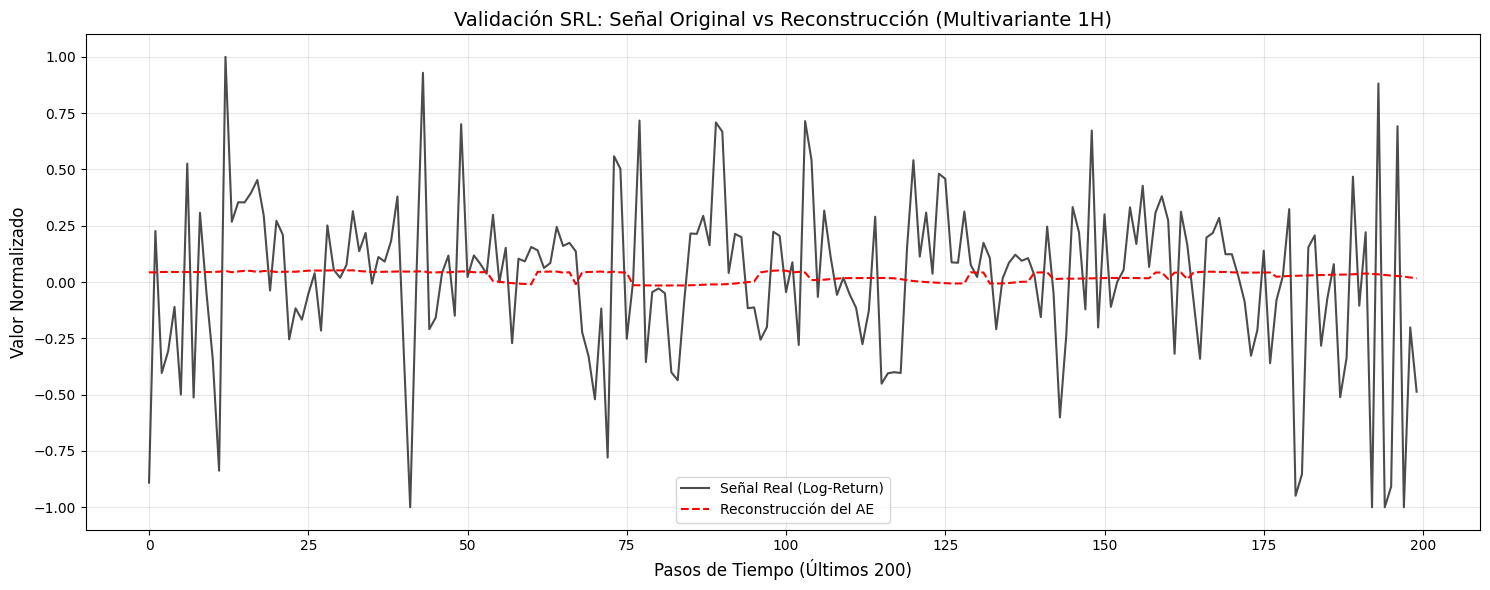

In [5]:
# --- 1. Preparar datos multivariantes para la visualización ---
file_path_1h = f'../data/{foldername}/01-output-{data_name}_1h-from-{from_safe}-until-{until_safe}-log-return.csv'
df_vis_1h = pd.read_csv(file_path_1h, parse_dates=['date'], index_col='date')

# Crucial: Usar la función de utils para tener las 3 columnas
from src.utils import prepare_multivariate_data
df_vis_1h = prepare_multivariate_data(df_vis_1h)

feature_cols = [
    'normalized_outliers_processed_log_return', 
    'normalized_range', 
    'normalized_tradecount'
]
features_vis_1h = df_vis_1h[feature_cols]

# --- 2. Inicializar modelo con dimensión 3 ---
input_dim_1h = features_vis_1h.shape[1] # Esto ahora será 3
model_1h = TemporalAutoencoder(input_dim_1h, HIDDEN_DIM, LATENT_DIM).to(device)

# --- 3. Cargar pesos y poner en modo evaluación ---
model_1h.load_state_dict(torch.load(f'../results/{foldername}/autoencoder_1h.pth', map_location=device))
model_1h.eval()

print(f"Visualización preparada: Modelo cargado con input_dim={input_dim_1h}")

# --- 4. Preparar la muestra (Últimos 200 puntos) ---
# Generamos las ventanas de las 3 variables
X_vis = create_sliding_windows(features_vis_1h, WINDOW_SIZE)
test_inputs = X_vis[-200:].to(device) # Enviamos al Ferrari

with torch.no_grad():
    # El modelo reconstruye las 3 variables a la vez
    reconstructed, _ = model_1h(test_inputs)
    
# --- 5. Convertir a numpy para graficar ---
# Como el modelo devuelve 3 columnas, pillamos la [0] que es el log-return
# .cpu() es obligatorio para sacar los datos de la tarjeta gráfica al gráfico
original_signal = test_inputs[:, -1, 0].cpu().numpy() 
reconstructed_signal = reconstructed[:, -1, 0].cpu().numpy()

# --- 6. GENERACIÓN DEL GRÁFICO ---
plt.figure(figsize=(15, 6))

plt.plot(original_signal, label='Señal Real (Log-Return)', color='black', alpha=0.7, linewidth=1.5)
plt.plot(reconstructed_signal, label='Reconstrucción del AE', color='red', linestyle='--', linewidth=1.5)

plt.title('Validación SRL: Señal Original vs Reconstrucción (Multivariante 1H)', fontsize=14)
plt.xlabel('Pasos de Tiempo (Últimos 200)', fontsize=12)
plt.ylabel('Valor Normalizado', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Como vemos, La capacidad del Autoencoder para replicar los movimientos de la señal original indica que el espacio latente de 16 dimensiones ($s_t$) ha capturado con éxito la varianza y la estructura de los datos.

Se observa que la reconstrucción (línea roja) tiende a ignorar micro-fluctuaciones extremas o "picos de ruido", manteniendo la trayectoria fundamental. Este efecto de suavizado es una propiedad intrínseca del "cuello de botella" de la red, lo que proporciona al agente de trading una representación más limpia y menos errática.